# TIF1501 — Praktik Pertemuan 1
## Studi Kasus Kaggle: Google Play Store Apps

**Mata Kuliah:** Statistika Dan Probabilitas (TIF1501) · 3 SKS · Semester 5  
**Program Studi Teknik Informatika — FTI UNISKA MAB Banjarmasin**  
**Pendamping Modul Pertemuan 1** — Aktivitas Discovery Learning (menit ke-75 sampai ke-105) dan LKM-01 Bagian B.

---

**Identitas Pengerjaan** *(isi lebih dulu sebelum menjalankan sel apa pun)*

| Butir | Isian |
|---|---|
| Nama |Putri Sal Sabila |
| NIM  |2410010086 |
| Kelas / Kelompok | 5 A Reguler pagi Banjarmasin |
| Tanggal pengerjaan | 26 September 2026 |
| Lingkungan kerja | Kaggle Notebook / Google Colab / Anaconda lokal *(coret yang tidak dipakai)* |


## 1. Tujuan Pembelajaran yang Akan Dituntaskan

Setelah menyelesaikan notebook ini, mahasiswa mampu:

1. Menjelaskan perbedaan **statistika deskriptif, statistika inferensial, dan probabilitas** beserta arah penalarannya.
2. Menunjukkan minimal **tiga peran statistika/probabilitas** dalam Machine Learning, analisis kinerja algoritma, dan riset Informatika.
3. Mengklasifikasikan variabel ke dalam skala **nominal, ordinal, interval, atau rasio** serta menentukan operasi statistik yang sah untuk tiap skala.
4. Membedakan **populasi, sampel, parameter, dan statistik**, serta menjelaskan konsekuensi teknik sampling terhadap kesimpulan.


## 2. Identitas Dataset

| Butir | Keterangan |
|---|---|
| Nama | Google Play Store Apps |
| Penyusun | Lavanya Gupta |
| Tautan | https://www.kaggle.com/datasets/lava18/google-play-store-apps |
| Berkas utama | `googleplaystore.csv` |
| Ukuran | 10.841 baris, 13 kolom |
| Cara pengumpulan | Web scraping halaman Google Play Store |
| Waktu pengambilan | Dipublikasikan Februari 2019 |
| Sitasi wajib | L. Gupta, "Google Play Store Apps," Feb 2019. Kaggle. |

**Tiga belas kolom:** `App`, `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type`, `Price`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`.

> **Catatan kejujuran data.** Dataset ini bukan dataset bersih. Ada nilai hilang pada `Rating`, ada baris yang kolomnya bergeser sehingga nilainya tidak masuk akal, dan ada duplikat nama aplikasi. Semua itu bukan cacat bagi praktik kita, melainkan bahan pelajaran. Data nyata memang begitu.


## 3. Persiapan Lingkungan Kerja

### Opsi A — Kaggle Notebook (dianjurkan, tanpa instalasi)
1. Buat akun gratis di https://www.kaggle.com menggunakan surel kampus.
2. Buka halaman dataset, tekan tombol **New Notebook**. Kaggle otomatis melampirkan dataset ke notebook.
3. Berkas akan tersedia di jalur `/kaggle/input/google-play-store-apps/googleplaystore.csv`.
4. Ubah judul notebook menjadi `TIF1501_P01_<NIM>_<Nama>`.
5. Setelah selesai, gunakan **File → Download** untuk mengunduh `.ipynb`, dan **File → Save as PDF** untuk berkas PDF-nya.

### Opsi B — Google Colab
1. Unduh `googleplaystore.csv` dari Kaggle melalui tombol **Download**.
2. Unggah berkas ke Colab lewat panel Files, lalu gunakan `JALUR = 'googleplaystore.csv'` pada sel di bawah.

### Opsi C — Anaconda di komputer sendiri
Letakkan `googleplaystore.csv` satu folder dengan notebook, lalu ubah `JALUR` seperti Opsi B.

**Sel di bawah harus dijalankan lebih dulu.** Sesuaikan variabel `JALUR` dengan opsi Anda.


In [9]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# --- Sesuaikan salah satu baris di bawah dengan opsi Anda ---
JALUR = '/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv'   # Opsi A (Kaggle)
#JALUR = 'googleplaystore.csv'                                      # Opsi B atau C

df = pd.read_csv(JALUR)
print('Ukuran data:', df.shape)
df.head()

Ukuran data: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 4. Skenario Kasus

> Anda bergabung dengan tim kecil yang berencana merilis aplikasi Android pertama mereka. Manajer produk bertanya:
>
> **"Kategori apa yang paling menjanjikan, dan apakah aplikasi berbayar mendapat penilaian lebih baik daripada yang gratis?"**
>
> Sebelum menjawab, Anda harus lebih dulu memastikan pertanyaan apa yang sebenarnya bisa dijawab dengan data ini, variabel mana yang boleh dihitung rata-ratanya, dan sejauh mana kesimpulan Anda sah digeneralisasi.

Pertemuan 1 tidak menuntut Anda menjawab pertanyaan manajer itu. Yang dituntut adalah kemampuan **menilai apakah data ini layak dipakai untuk menjawabnya**. Jawaban penuhnya baru mungkin setelah Pertemuan 14.


---
# TAHAP 1 — Deskriptif, Inferensial, dan Probabilitas
*Menjawab Tujuan Pembelajaran nomor 1*

## 5.1 Ketiga arah penalaran pada satu dataset

| Jenis pernyataan | Contoh pada dataset ini | Ciri pengenal |
|---|---|---|
| **Deskriptif** | "Dari 10.841 baris yang tercatat, rata-rata rating adalah 4,19." | Hanya bicara tentang data yang ada di tangan. Tidak ada klaim di luar itu |
| **Inferensial** | "Berdasarkan data ini, kami yakin 95% bahwa rata-rata rating seluruh aplikasi di Play Store pada Februari 2019 berada antara 4,17 dan 4,21." | Menarik kesimpulan tentang populasi yang lebih besar, disertai ukuran ketidakpastian |
| **Probabilitas** | "Bila satu aplikasi diambil acak dari populasi yang rata-ratanya 4,19 dengan simpangan baku 0,54, berapa peluang ratingnya di atas 4,5?" | Model sudah diketahui, yang dicari adalah peluang munculnya data tertentu |

Perhatikan arah panahnya. Deskriptif berhenti di data. Inferensial bergerak **dari data menuju model**. Probabilitas bergerak **dari model menuju data**.

## 5.2 Ringkasan deskriptif sederhana


In [11]:
# --- Ringkasan deskriptif sederhana ---
print('Jumlah baris          :', len(df))
print('Rating tidak kosong   :', df['Rating'].notna().sum())
print('Rating kosong         :', df['Rating'].isna().sum())
print()
print('Rata-rata rating      : %.4f' % df['Rating'].mean())
print('Median rating         : %.4f' % df['Rating'].median())
print('Simpangan baku rating : %.4f' % df['Rating'].std(ddof=1))
print('Rating minimum        :', df['Rating'].min())
print('Rating maksimum       :', df['Rating'].max())


Jumlah baris          : 10841
Rating tidak kosong   : 9367
Rating kosong         : 1474

Rata-rata rating      : 4.1933
Median rating         : 4.3000
Simpangan baku rating : 0.5374
Rating minimum        : 1.0
Rating maksimum       : 19.0


### Perhatikan nilai maksimumnya

Bila muncul angka yang tidak mungkin untuk skala 1 sampai 5, berarti Anda baru saja menemukan baris yang kolomnya bergeser saat proses scraping. Telusuri baris itu.


In [12]:
# --- Menemukan baris bermasalah ---
aneh = df[df['Rating'] > 5]
print('Jumlah baris dengan rating mustahil:', len(aneh))
aneh


Jumlah baris dengan rating mustahil: 1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


### Pertanyaan untuk dijawab di sel Markdown berikutnya

Mengapa satu baris rusak dari 10.841 baris tetap penting untuk dilaporkan? Apa yang terjadi pada nilai rata-rata bila baris itu dibiarkan?


**Jawaban Anda:**

Karena satu baris yang rusak tetap bisa memengaruhi hasil analisis, terutama nilai rata-rata. Jika dibiarkan, nilai rata-rata bisa menjadi tidak tepat atau bias karena data yang salah ikut dihitung.


## 5.3 Tugas Tahap 1

Tuliskan **tiga pertanyaan** berbeda yang bisa diajukan pada dataset ini: satu deskriptif, satu inferensial, dan satu probabilitas. Untuk masing-masing, jelaskan dalam satu kalimat mengapa ia masuk kategori tersebut.

Pertanyaan tidak boleh sekadar menyalin contoh pada tabel 5.1.


**Jawaban Tugas Tahap 1:**

1. **Pertanyaan deskriptif:** Berapa rata-rata rating aplikasi berdasarkan kategori aplikasi di Google Play Store?
   - *Alasan penggolongan:* Termasuk deskriptif karena hanya menggambarkan kondisi data yang sudah ada pada dataset.

2. **Pertanyaan inferensial:**Apakah aplikasi yang memiliki ukuran file lebih besar cenderung mempunyai rating yang lebih tinggi?
   - *Alasan penggolongan:* Termasuk inferensial karena ingin melihat hubungan pada data dan menarik kesimpulan dari pola yang ditemukan.
3. **Pertanyaan probabilitas:** Berapa peluang sebuah aplikasi yang dipilih secara acak memiliki rating minimal 4,5?
   - *Alasan penggolongan:* Termasuk probabilitas karena menghitung kemungkinan terjadinya suatu kejadian berdasarkan data yang tersedia.


---
# TAHAP 2 — Peran Statistika dalam Bidang Informatika
*Menjawab Tujuan Pembelajaran nomor 2*

Dataset yang sama dapat menopang tiga peran berbeda. Jalankan kodenya, lalu kaitkan dengan penjelasannya.

## 6.1 Peran pertama — fondasi Machine Learning


In [13]:
# Sebaran rating per jenis aplikasi — cikal bakal fitur untuk model klasifikasi
print(df.groupby('Type')['Rating'].agg(['count', 'mean', 'std']).round(4))


      count     mean     std
Type                        
0         1  19.0000     NaN
Free   8719   4.1862  0.5123
Paid    647   4.2666  0.5475


Bila kelak Anda membangun model yang memprediksi apakah sebuah aplikasi akan sukses, keluaran di atas adalah bahan mentahnya. Naïve Bayes, yang akan dibahas pada Pertemuan 3, bekerja persis dengan menghitung peluang setiap kelas berdasarkan sebaran seperti ini. Gaussian Naïve Bayes pada Pertemuan 7 malah mengandaikan setiap fitur numerik berdistribusi Normal, sebuah asumsi yang harus diperiksa lebih dulu, bukan diterima begitu saja.

## 6.2 Peran kedua — analisis kinerja dan kapasitas sistem


In [15]:
# Ubah Size menjadi angka dalam satuan megabita
def ke_megabita(nilai):
    if not isinstance(nilai, str):
        return np.nan
    nilai = nilai.strip()
    if nilai.endswith('M'):
        return float(nilai[:-1])
    if nilai.endswith('k'):
        return float(nilai[:-1]) / 1024
    return np.nan          # mencakup 'Varies with device'

df['Size_MB'] = df['Size'].apply(ke_megabita)

print('Aplikasi dengan ukuran tercatat :', df['Size_MB'].notna().sum())
print('Ukuran rata-rata (MB)  : %.2f' % df['Size_MB'].mean())
print('Ukuran median   (MB)   : %.2f' % df['Size_MB'].median())
print('Persentil 95    (MB)   : %.2f' % df['Size_MB'].quantile(0.95))


Aplikasi dengan ukuran tercatat : 9145
Ukuran rata-rata (MB)  : 21.52
Ukuran median   (MB)   : 13.00
Persentil 95    (MB)   : 73.00


Perhatikan jarak antara mean dan median. Bila mean jauh lebih besar dari median, sebarannya menceng ke kanan. Dalam perencanaan kapasitas penyimpanan atau kuota unduhan, melaporkan rata-rata pada data menceng adalah kesalahan klasik. Persentil 95 jauh lebih berguna, dan itulah alasan SLA layanan biasanya ditulis dalam persentil, bukan rata-rata. Pembahasan lengkapnya ada di Pertemuan 9.

## 6.3 Peran ketiga — tulang punggung riset ilmiah


In [16]:
# Berapa banyak kategori, dan seberapa timpang sebarannya?
jumlah_kategori = df['Category'].value_counts()
print('Banyak kategori:', jumlah_kategori.shape[0])
print(jumlah_kategori.head(10))
print()
print('Lima kategori teratas menyumbang %.1f%% dari seluruh baris'
      % (100 * jumlah_kategori.head(5).sum() / len(df)))


Banyak kategori: 34
Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382
Name: count, dtype: int64

Lima kategori teratas menyumbang 45.0% dari seluruh baris


Bila Anda menulis skripsi dengan dataset ini, angka-angka di atas wajib masuk ke Bab Metode. Tanpa itu, pembaca tidak bisa menilai apakah kesimpulan Anda berlaku umum atau hanya mencerminkan kategori yang kebetulan paling banyak datanya.


## 6.4 Tugas Tahap 2

Tuliskan **tiga peran statistika/probabilitas** yang terlihat pada dataset ini, masing-masing disertai satu keluaran kode di atas sebagai buktinya. Sebutkan pula satu peran keempat di bidang Informatika yang **tidak** dapat ditunjukkan dengan dataset ini, beserta alasannya.


**Jawaban Tugas Tahap 2:**

1. **Peran pertama:** Mendeskripsikan Data
Statistika digunakan untuk menggambarkan kondisi data yang ada.
   - *Bukti dari keluaran kode:* output df.shape menunjukkan ukuran dataset 10.841 baris dan 13 kolom.

2. **Peran kedua:**Menghitung Nilai Statistik
Statistika dapat digunakan untuk menghitung nilai seperti rata-rata rating aplikasi.
   - *Bukti dari keluaran kode:* output df['Rating'].mean() menunjukkan rata-rata rating.
3. **Peran ketiga:** Menggunakan Probabilitas
Probabilitas dapat digunakan untuk melihat peluang sebuah aplikasi memiliki rating tertentu berdasarkan data.
   - *Bukti dari keluaran kode:* hasil perhitungan jumlah aplikasi dengan rating minimal 4,5 dibandingkan dengan jumlah seluruh aplikasi.
4. **Peran yang TIDAK dapat ditunjukkan dengan dataset ini:** Prediksi menggunakan Machine Learning
   - *Alasan:* Dataset ini hanya berisi data aplikasi dan rating, sedangkan prediksi membutuhkan pembuatan dan pengujian model Machine Learning terlebih dahulu.

---
# TAHAP 3 — Skala Pengukuran
*Menjawab Tujuan Pembelajaran nomor 3 — bagian paling menentukan dalam praktik ini*

## 7.1 Jebakan: tipe data bukan skala pengukuran

Jalankan sel berikut dan perhatikan hasilnya:


In [17]:
print(df.dtypes)


App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object


Python akan melaporkan hampir semua kolom sebagai `object`, yaitu teks. Itu adalah **tipe data**, keputusan teknis penyimpanan. **Skala pengukuran** adalah sifat variabelnya, dan keduanya sering tidak sejalan:

| Kolom | Tipe data menurut pandas | Skala pengukuran sebenarnya | Mengapa berbeda |
|---|---|---|---|
| `Installs` | object (teks) | **Ordinal** | Isinya `"10,000+"`, `"1,000,000+"`. Ada urutan yang jelas, tetapi jarak antar kelompok tidak sama, dan angkanya adalah batas bawah kelompok, bukan hitungan sebenarnya |
| `Price` | object (teks) | **Rasio** | Isinya `"$4.99"`. Setelah tanda dolar dibuang, ada nol mutlak dan rasio bermakna: aplikasi $10 benar-benar dua kali lipat harga aplikasi $5 |
| `Rating` | float64 | **Ordinal, sering diperlakukan interval** | Angka 1 sampai 5. Apakah selisih 4 ke 5 sama dengan selisih 2 ke 3? Secara ketat tidak, tetapi praktik umum memperlakukannya sebagai interval. Wajib disebutkan sebagai asumsi |
| `Last Updated` | object (teks) | **Interval** | Tanggal. Selisihnya bermakna (60 hari), tetapi tidak ada nol mutlak sehingga rasio antar tanggal tidak bermakna |

> **Inilah butir yang paling sering keliru dalam LKM-01: menyalin keluaran `df.dtypes` lalu menyebutnya skala pengukuran. Nilainya akan rendah.**

## 7.2 Membersihkan kolom agar siap dihitung


In [18]:
bersih = df.copy()

# Buang baris yang kolomnya bergeser (rating mustahil)
bersih = bersih[(bersih['Rating'].isna()) | (bersih['Rating'] <= 5)]

# Price: buang tanda dolar, ubah ke angka -> skala RASIO
bersih['Price_USD'] = pd.to_numeric(
    bersih['Price'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)

# Reviews: ubah ke angka -> skala RASIO
bersih['Reviews_n'] = pd.to_numeric(bersih['Reviews'], errors='coerce')

# Installs: buang koma dan tanda plus -> nilai ambang tiap kelompok
bersih['Installs_num'] = pd.to_numeric(
    bersih['Installs'].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('+', '', regex=False),
    errors='coerce'
)

print(bersih[['Price', 'Price_USD', 'Reviews', 'Reviews_n',
              'Installs', 'Installs_num']].head(10))
print()
print('Gagal dikonversi -> Price:', bersih['Price_USD'].isna().sum(),
      '| Reviews:', bersih['Reviews_n'].isna().sum(),
      '| Installs:', bersih['Installs_num'].isna().sum())


  Price  Price_USD Reviews  Reviews_n     Installs  Installs_num
0     0        0.0     159        159      10,000+         10000
1     0        0.0     967        967     500,000+        500000
2     0        0.0   87510      87510   5,000,000+       5000000
3     0        0.0  215644     215644  50,000,000+      50000000
4     0        0.0     967        967     100,000+        100000
5     0        0.0     167        167      50,000+         50000
6     0        0.0     178        178      50,000+         50000
7     0        0.0   36815      36815   1,000,000+       1000000
8     0        0.0   13791      13791   1,000,000+       1000000
9     0        0.0     121        121      10,000+         10000

Gagal dikonversi -> Price: 0 | Reviews: 0 | Installs: 0


## 7.3 Memperlakukan Installs sebagai ordinal yang sebenarnya


In [19]:
urutan = ['0+', '1+', '5+', '10+', '50+', '100+', '500+',
          '1,000+', '5,000+', '10,000+', '50,000+', '100,000+',
          '500,000+', '1,000,000+', '5,000,000+', '10,000,000+',
          '50,000,000+', '100,000,000+', '500,000,000+', '1,000,000,000+']

bersih['Installs_ord'] = pd.Categorical(
    bersih['Installs'], categories=urutan, ordered=True
)

print(bersih['Installs_ord'].value_counts().sort_index())
print()
print('Modus  :', bersih['Installs_ord'].mode()[0])

d_urut = bersih['Installs_ord'].dropna().sort_values()
print('Median :', d_urut.iloc[len(d_urut) // 2])


Installs_ord
0+                  14
1+                  67
5+                  82
10+                386
50+                205
100+               719
500+               330
1,000+             907
5,000+             477
10,000+           1054
50,000+            479
100,000+          1169
500,000+           539
1,000,000+        1579
5,000,000+         752
10,000,000+       1252
50,000,000+        289
100,000,000+       409
500,000,000+        72
1,000,000,000+      58
Name: count, dtype: int64

Modus  : 1,000,000+
Median : 100,000+


**Perhatikan apa yang tidak dilakukan di sini:** kita tidak menghitung rata-rata `Installs_ord`. Untuk data ordinal, yang sah hanyalah modus, median, dan persentil.

Sekarang jalankan perbandingan berikut dan pikirkan maknanya:


In [20]:
print('Rata-rata Installs_num : %.1f' % bersih['Installs_num'].mean())
print('Median  Installs_num   : %.1f' % bersih['Installs_num'].median())
print('Modus kelompok Installs:', bersih['Installs_ord'].mode()[0])


Rata-rata Installs_num : 15464338.9
Median  Installs_num   : 100000.0
Modus kelompok Installs: 1,000,000+


Angka rata-rata itu **bisa** dihitung Python, tetapi maknanya meragukan. Nilai `1,000,000+` diperlakukan sebagai tepat 1.000.000, padahal aplikasi dengan 900 juta unduhan juga masuk kelompok `500,000,000+`. Mesin tidak akan memperingatkan Anda. Hanya pemahaman skala pengukuran yang bisa.

## 7.4 Operasi yang sah untuk tiap skala


In [21]:
# NOMINAL — hanya frekuensi, proporsi, modus
print('== Content Rating (nominal) ==')
print(bersih['Content Rating'].value_counts())
print((bersih['Content Rating'].value_counts(normalize=True) * 100).round(2))
print()

# ORDINAL — modus, median, persentil
print('== Installs (ordinal) ==')
print('Modus:', bersih['Installs_ord'].mode()[0])
print()

# RASIO — seluruh operasi termasuk mean, simpangan baku, dan pembagian
print('== Price dalam USD (rasio) ==')
print('Mean   : %.4f' % bersih['Price_USD'].mean())
print('Median : %.4f' % bersih['Price_USD'].median())
print('Std    : %.4f' % bersih['Price_USD'].std(ddof=1))
berbayar = bersih[bersih['Price_USD'] > 0]['Price_USD']
print('Hanya aplikasi berbayar -> n = %d, mean = %.4f' % (len(berbayar), berbayar.mean()))


== Content Rating (nominal) ==
Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64
Content Rating
Everyone           80.39
Teen               11.14
Mature 17+          4.60
Everyone 10+        3.82
Adults only 18+     0.03
Unrated             0.02
Name: proportion, dtype: float64

== Installs (ordinal) ==
Modus: 1,000,000+

== Price dalam USD (rasio) ==
Mean   : 1.0274
Median : 0.0000
Std    : 15.9497
Hanya aplikasi berbayar -> n = 800, mean = 13.9208


Bandingkan mean `Price_USD` pada seluruh data dengan mean pada aplikasi berbayar saja. Perbedaannya besar, karena sekitar 92% aplikasi berharga nol. Ini contoh bagaimana **memilih subpopulasi yang tepat** lebih menentukan daripada memilih rumus.


## 7.5 Tugas Tahap 3 — Kamus Variabel (bobot penilaian terbesar)

Isi tabel berikut untuk **seluruh 13 kolom asli**. Ketik langsung di sel Markdown di bawah.

Ketentuan:
1. Kolom "Alasan penetapan skala" wajib diisi, minimal satu kalimat, dan tidak boleh sekadar mengulang nama skalanya.
2. Untuk setiap kolom yang tipe datanya berbeda arah dengan skalanya, beri tanda dan jelaskan perbedaannya.
3. Sebutkan kolom mana saja yang **tidak boleh** dihitung rata-ratanya, beserta alasannya.
4. Tetapkan satu kolom sebagai calon **variabel terikat** dan dua kolom sebagai calon **variabel bebas** untuk pertanyaan manajer produk pada bagian 4.


**Kamus Variabel:**

| Nama kolom | Deskripsi | Tipe data pandas | Skala pengukuran | Alasan penetapan skala | Contoh nilai | Ukuran pemusatan yang sah |
|---|---|---|---|---|---|---|
| App |Nama Aplikasi | object |Nominal |Hanya berfungsi sebagai nama atau identitas aplikasi dan tidak memiliki urutan. |WhatsApp |Modus |
| Category |Ketegori Aplikasi | object |Nominal |Kategori hanya menunjukkan kelompok aplikasi dan tidak memiliki tingkatan. |GAME |Modus |
| Rating |Nilai rating aplikasi | float64 |Interval |Nilai rating memiliki jarak yang dapat dibandingkan dan digunakan untuk melihat perbedaan nilai. |4.5 |Mean, median, modus |
| Reviews |Jumlah ulasan aplikasi | object |Rasio |Menunjukkan jumlah ulasan, memiliki nol yang bermakna dan dapat dibandingkan secara kuantitatif. |159 |Mean, median, modus |
| Size |Ukuran aplikasi | object |Rasio| Ukuran aplikasi dapat diukur dan memiliki nilai nol yang bermakna.| 19M| Mean, median, modus|
| Installs |Jumlah pemasangan aplikasi | object | Rasio| Jumlah pemasangan merupakan data hitungan dan memiliki nol yang bermakna.|1,000,000+ |Mean, median, modus |
| Type |Jenis aplikasi | object |Nominal |Hanya menunjukkan jenis aplikasi dan tidak memiliki urutan. |aplikasi dan tidak memiliki urutan.
Free |Modus |
| Price |Harga aplikasi | object |Rasio |Harga dapat dibandingkan secara kuantitatif dan memiliki nilai nol untuk aplikasi gratis. |$4.99 |Mean, median, modus |
| Content Rating |Kelompok usia pengguna | object |Ordinal |Memiliki tingkatan berdasarkan kelompok usia pengguna. | Everyone|Median, modus |
| Genres |Genre aplikasi | object |Nominal | Genre hanya menunjukkan kategori atau jenis aplikasi tanpa urutan.| Education|Modus |
| Last Updated |Tanggal terakhir diperbarui | object |Interval | Perbedaan antar tanggal dapat dihitung, tetapi tidak memiliki titik nol yang mutlak.|January 10, 2018 |Mean, median, modus |
| Current Ver |Versi aplikasi saat ini | object |Ordinal |Versi dapat menunjukkan urutan perkembangan, tetapi selisih antar versi tidak menunjukkan jarak yang pasti. |4.2.1 |Median, modus |
| Android Ver |Versi android minimum | object |Ordinal |Versi Android memiliki urutan dari versi yang lebih lama ke yang lebih baru. |4.0 and up |Median, modus |

**Kolom yang TIDAK BOLEH dihitung rata-ratanya:**

- App (alasan: hanya berupa nama/identitas aplikasi)
- Category (alasan:hanya menunjukkan kategori aplikasi)
- Type (alasan: hanya menunjukkan jenis aplikasi)

**Calon variabel terikat:** Rating

**Calon variabel bebas (dua kolom):**
1. Reviews
2. Installs

---
# TAHAP 4 — Populasi, Sampel, Parameter, Statistik
*Menjawab Tujuan Pembelajaran nomor 4*

## 8.1 Pertanyaan pokok: dataset ini populasi atau sampel?

Jawabannya bergantung pada populasi yang Anda klaim.

| Populasi yang diklaim | Status dataset | Konsekuensi |
|---|---|---|
| "10.841 aplikasi yang tercatat dalam berkas ini" | **Populasi** | Semua hitungan adalah parameter. Tidak ada inferensi, tidak ada ketidakpastian, tetapi kesimpulannya juga tidak berguna untuk siapa pun |
| "Seluruh aplikasi di Google Play Store pada Februari 2019" | **Sampel** | Semua hitungan adalah statistik. Perlu inferensi dan selang kepercayaan. Perlu diperiksa apakah sampelnya representatif |
| "Seluruh aplikasi Android hari ini" | **Sampel yang buruk** | Data berusia bertahun-tahun. Ekosistem aplikasi berubah cepat. Generalisasi tidak sah |

> **Status sebuah dataset tidak melekat pada datanya, melainkan pada klaim yang Anda buat tentangnya.**

## 8.2 Lambang parameter dan statistik


In [22]:
r = bersih['Rating'].dropna()

print('Banyak pengamatan (n)        : %d'   % len(r))
print('Rata-rata sampel (x-bar)     : %.4f' % r.mean())
print('Simpangan baku sampel (s)    : %.4f' % r.std(ddof=1))
print()
print('Nilai mu dan sigma untuk seluruh Play Store: TIDAK DIKETAHUI')


Banyak pengamatan (n)        : 9366
Rata-rata sampel (x-bar)     : 4.1918
Simpangan baku sampel (s)    : 0.5152

Nilai mu dan sigma untuk seluruh Play Store: TIDAK DIKETAHUI


Catat baik-baik: `ddof=1` pada baris simpangan baku. Itulah pembeda antara rumus **s** (statistik, pembagi n−1) dan **σ** (parameter, pembagi n). Pandas memakai `ddof=1` sebagai bawaan justru karena data biasanya diperlakukan sebagai sampel. Alasan matematis di balik n−1 akan dibahas pada Pertemuan 11.

## 8.3 Membuktikan sendiri bahwa statistik berubah antar sampel


In [23]:
print('%-8s %-10s %-10s' % ('Sampel', 'n', 'x-bar'))
print('-' * 30)
for i in range(1, 11):
    contoh = r.sample(n=100, random_state=i)
    print('%-8d %-10d %-10.4f' % (i, len(contoh), contoh.mean()))

print()
print('Rata-rata seluruh data (acuan): %.4f' % r.mean())


Sampel   n          x-bar     
------------------------------
1        100        4.1470    
2        100        4.1820    
3        100        4.2340    
4        100        4.2690    
5        100        4.1490    
6        100        4.2600    
7        100        4.2080    
8        100        4.2530    
9        100        4.2060    
10       100        4.1940    

Rata-rata seluruh data (acuan): 4.1918


**Inilah inti seluruh statistika inferensial.** Sepuluh sampel acak dari data yang sama menghasilkan sepuluh nilai x̄ yang berbeda, dan tidak satu pun persis sama dengan nilai acuannya. Keragaman itu bukan kesalahan, melainkan sifat alami penarikan sampel. Mengukur besarnya keragaman itulah pekerjaan Pertemuan 11, dan penjelasan mengapa keragamannya berbentuk lonceng adalah Teorema Limit Pusat pada Pertemuan 7.

Lanjutkan dengan mengamati pengaruh ukuran sampel:


In [24]:
for n in [10, 30, 100, 500, 2000]:
    hasil = [r.sample(n=n, random_state=k).mean() for k in range(200)]
    print('n = %-5d | sebaran x-bar: min %.4f, maks %.4f, simpangan baku %.4f'
          % (n, min(hasil), max(hasil), np.std(hasil, ddof=1)))


n = 10    | sebaran x-bar: min 3.6500, maks 4.5200, simpangan baku 0.1569
n = 30    | sebaran x-bar: min 3.9133, maks 4.3933, simpangan baku 0.0873
n = 100   | sebaran x-bar: min 4.0260, maks 4.3440, simpangan baku 0.0517
n = 500   | sebaran x-bar: min 4.1328, maks 4.2696, simpangan baku 0.0255
n = 2000  | sebaran x-bar: min 4.1643, maks 4.2186, simpangan baku 0.0104


Semakin besar n, semakin rapat sebaran x̄ di sekitar nilai acuan. Tuliskan pengamatan Anda pada sel Markdown berikut.


**Pengamatan Anda tentang pengaruh n terhadap sebaran x̄:**

Semakin besar nilai n, sebaran x̄ menjadi semakin sempit dan lebih terkonsentrasi di sekitar rata-rata. Artinya, rata-rata sampel cenderung lebih stabil ketika ukuran sampel semakin besar.


## 8.4 Bias yang tidak bisa diperbaiki oleh besarnya n


In [25]:
print('Duplikat nama aplikasi :', bersih['App'].duplicated().sum())
print('Aplikasi unik          :', bersih['App'].nunique())
print()
print('Proporsi jenis aplikasi:')
print((bersih['Type'].value_counts(normalize=True) * 100).round(2))
print()
print('Rating kosong          : %d (%.2f%%)'
      % (bersih['Rating'].isna().sum(),
         100 * bersih['Rating'].isna().sum() / len(bersih)))


Duplikat nama aplikasi : 1181
Aplikasi unik          : 9659

Proporsi jenis aplikasi:
Type
Free    92.62
Paid     7.38
Name: proportion, dtype: float64

Rating kosong          : 1474 (13.60%)


Tiga temuan di atas masing-masing adalah ancaman terhadap generalisasi:

1. **Duplikat.** Satu aplikasi yang tercatat berkali-kali mendapat bobot lebih besar dari yang seharusnya. Apakah Anda membuang duplikatnya? Keputusan itu wajib dilaporkan.
2. **Ketimpangan gratis dan berbayar.** Bila hampir seluruh data adalah aplikasi gratis, kesimpulan tentang aplikasi berbayar berdiri di atas sampel yang jauh lebih kecil daripada yang terlihat dari angka 10.841.
3. **Rating yang kosong.** Aplikasi tanpa rating besar kemungkinan adalah aplikasi baru atau tidak populer. Membuang begitu saja baris yang ratingnya kosong berarti diam-diam mengubah populasi yang Anda teliti menjadi "aplikasi yang cukup populer untuk mendapat rating". Ini contoh nyata *nonresponse bias*.

Tambahkan satu ancaman lagi yang melekat pada cara pengumpulannya: data ini hasil scraping satu kali. Aplikasi yang sudah dihapus sebelum Februari 2019 tidak pernah masuk, dan aplikasi yang rilis setelahnya juga tidak. Teknik pengambilannya bukan *simple random sampling*, melainkan lebih dekat ke *accidental sampling* atas apa pun yang berhasil diambil oleh program scraper.

> **Menambah data menjadi sepuluh kali lipat tidak menyembuhkan satu pun dari empat masalah di atas.** Besarnya n hanya memperkecil galat acak. Galat sistematis harus diperbaiki di tahap perancangan pengambilan data.


## 8.5 Tugas Tahap 4

Tulis satu paragraf **minimal 150 kata** yang menjawab: **populasi apa yang sebenarnya diwakili dataset ini?** Paragraf wajib memuat:

1. Rumusan populasi yang menurut Anda paling jujur.
2. Minimal tiga sumber bias yang sudah Anda temukan lewat kode di atas.
3. Satu kalimat yang menyatakan kesimpulan seperti apa yang **tidak boleh** ditarik dari dataset ini.
4. Usulan perbaikan teknik pengambilan data seandainya Anda yang merancang ulang pengumpulannya.


**Paragraf batas generalisasi (minimal 150 kata):**

Menurut saya, populasi yang sebenarnya diwakili oleh dataset ini adalah aplikasi yang tercatat dalam data Google Play Store pada saat data tersebut dikumpulkan, bukan seluruh aplikasi yang pernah atau sedang ada di Google Play Store. Dataset ini juga memiliki beberapa sumber bias. Pertama, terdapat data yang tidak lengkap atau memiliki format yang berbeda, misalnya pada kolom Rating, Size, dan beberapa kolom lainnya. Kedua, terdapat data yang tidak konsisten, seperti adanya nilai atau baris yang perlu diperiksa sebelum digunakan dalam analisis. Ketiga, dataset ini hanya mengambil data pada waktu tertentu sehingga aplikasi atau perubahan terbaru setelah data dikumpulkan tidak ikut terwakili. Selain itu, aplikasi yang masuk ke dalam dataset belum tentu mewakili semua aplikasi di Google Play Store secara keseluruhan. Karena itu, kesimpulan dari dataset ini tidak boleh langsung dianggap berlaku untuk seluruh aplikasi Android atau seluruh pengguna Google Play Store. Jika saya merancang ulang pengumpulan datanya, saya akan mengambil data dari lebih banyak aplikasi dengan waktu pengambilan yang berbeda, memastikan setiap kolom memiliki format yang konsisten, membersihkan data yang bermasalah, dan menggunakan teknik pengambilan sampel yang lebih teratur agar data yang diperoleh lebih mewakili populasi.


---
## Verifikasi Lingkungan Kerja

Lampirkan tangkapan layar keluaran sel berikut pada berkas PDF laporan, sesuai ketentuan LKM-01.


In [26]:
import numpy, pandas, scipy, matplotlib, seaborn, statsmodels
for m in (numpy, pandas, scipy, matplotlib, seaborn, statsmodels):
    print('%-12s %s' % (m.__name__, m.__version__))

print()
print('Ukuran dataframe:', df.shape)
print('Kolom            :', list(df.columns))


numpy        2.0.2
pandas       2.3.3
scipy        1.16.3
matplotlib   3.10.0
seaborn      0.13.2
statsmodels  0.14.6

Ukuran dataframe: (10841, 14)
Kolom            : ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Size_MB']


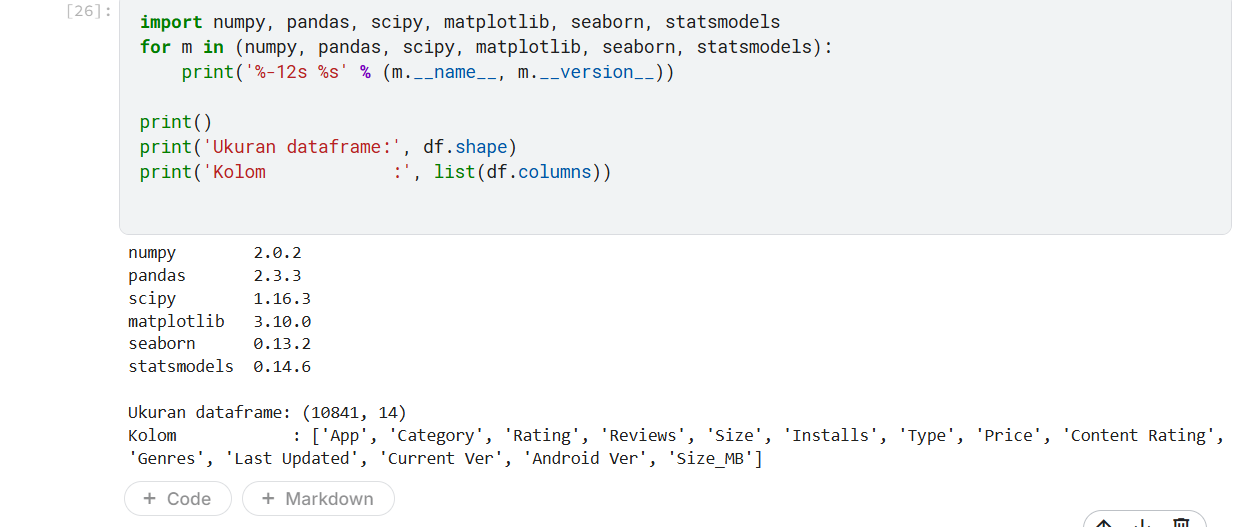


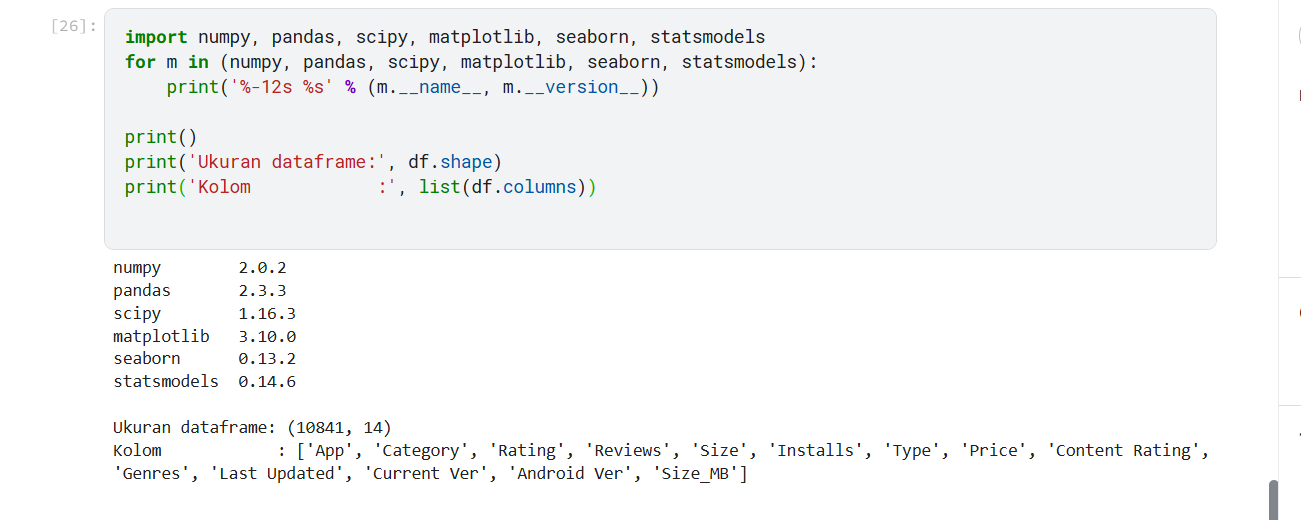

---
## 9. Daftar Luaran yang Dikumpulkan

Sebelum mengunggah, pastikan seluruh butir berikut sudah lengkap:

- [☑️ ] Notebook `TIF1501_P01_<NIM>_<Nama>.ipynb` dapat dijalankan ulang dari awal tanpa galat
- [ ☑️] Ekspor PDF dari notebook
- [☑️ ] Kamus variabel 13 kolom sudah terisi lengkap (bagian 7.5)
- [☑️ ] Tiga pertanyaan penelitian sudah terisi beserta alasan penggolongannya (bagian 5.3)
- [☑️ ] Tiga peran statistika beserta bukti keluaran kode (bagian 6.4)
- [ ☑️] Paragraf batas generalisasi minimal 150 kata (bagian 8.5)
- [ ☑️] Pengamatan tentang pengaruh n terhadap sebaran x̄ sudah dituliskan (bagian 8.3)
- [☑️ ] Tangkapan layar verifikasi lingkungan sudah dilampirkan
- [☑️ ] Catatan Pengerjaan pada bagian bawah notebook sudah diisi

**Tenggat:** sebelum Pertemuan 2 dimulai, diunggah ke LMS.

**Penamaan berkas:** `TIF1501_P01_<NIM>_<Nama>.ipynb` dan `TIF1501_P01_<NIM>_<Nama>.pdf`


## 10. Catatan Pengerjaan

*Wajib diisi. Bila Anda memakai AI generatif untuk membantu, cantumkan bagian mana yang dibantu dan bagaimana Anda memverifikasinya. Anda harus mampu menjelaskan ulang setiap baris kode saat asistensi.*

**Isi catatan pengerjaan Anda di sini:**

Dalam pengerjaan praktikum ini saya menggunakan bantuan AI generatif untuk membantu memahami beberapa bagian materi, menyusun pertanyaan penelitian pada bagian 5.3, membantu merumuskan peran statistika pada bagian 6.4, serta membantu merapikan penjelasan pada bagian 7.5 dan 8.5. Kode tetap saya jalankan dan periksa kembali di Google Colab untuk memastikan dapat berjalan dan menghasilkan output yang sesuai. Saya juga memeriksa kembali hasil yang diperoleh dan menyesuaikan jawaban dengan dataset yang digunakan.


---
## 11. Peta Praktik terhadap Tujuan Pembelajaran

| Tujuan Pembelajaran P01 | Dijawab pada | Bukti yang dinilai |
|---|---|---|
| 1. Membedakan deskriptif, inferensial, dan probabilitas | Tahap 1 | Tiga pertanyaan penelitian pada 5.3 |
| 2. Menunjukkan tiga peran statistika dalam Informatika | Tahap 2 | Tiga peran + satu peran yang tidak dapat ditunjukkan pada 6.4 |
| 3. Mengklasifikasikan skala pengukuran | Tahap 3 | Kamus variabel 13 kolom pada 7.5 |
| 4. Membedakan populasi, sampel, parameter, statistik | Tahap 4 | Paragraf batas generalisasi pada 8.5 |

## 12. Kaitan ke Pertemuan Berikutnya

| Temuan pada praktik ini | Diselesaikan pada |
|---|---|
| Sebaran ukuran aplikasi menceng ke kanan, mean menyesatkan | Pertemuan 9 — ukuran pemusatan, IQR, dan pencilan |
| Ingin melihat pola rating antar kategori secara visual | Pertemuan 10 — visualisasi dan korelasi |
| x̄ berubah-ubah antar sampel, seberapa jauh dari μ? | Pertemuan 11 — distribusi sampling dan selang kepercayaan |
| Apakah aplikasi berbayar benar-benar dinilai lebih tinggi? | Pertemuan 14 — uji t dua sampel |
| Apakah jenis aplikasi berkaitan dengan kelompok content rating? | Pertemuan 14 — uji Chi-Square independensi |
| Bagaimana memprediksi kelas aplikasi dari fiturnya? | Pertemuan 3 dan 7 — Naïve Bayes dan Gaussian Naïve Bayes |

Simpan notebook ini. Beberapa pertanyaan di atas akan Anda jawab sendiri dengan data yang sama pada paruh kedua semester.

---

### Referensi

- Gupta, L. (2019). *Google Play Store Apps* [Dataset]. Kaggle. https://www.kaggle.com/datasets/lava18/google-play-store-apps
- Walpole, R. E., Myers, R. H., Myers, S. L., & Ye, K. (2017). *Probability and Statistics for Engineers and Scientists* (9th ed.). Pearson. Bab 1.
- Montgomery, D. C., & Runger, G. C. (2018). *Applied Statistics and Probability for Engineers* (7th ed.). Wiley. Bab 1 dan 6.
- Sugiyono. (2022). *Metode Penelitian Kuantitatif, Kualitatif, dan R&D* (2nd ed.). Alfabeta.

*Praktik Pendamping Modul Pertemuan 1 — Statistika Dan Probabilitas (TIF1501)*
*Program Studi Teknik Informatika, Fakultas Teknologi Informasi, UNISKA MAB Banjarmasin*
